In [83]:
from __future__ import annotations

from pathlib import Path
import re
from typing import Dict, Optional


def read_simulation_time(log_file: str | Path) -> Dict[str, Optional[float]]:
    """Read simulation timing information from an md-flexible logOutput file.

    Returns a dictionary with:
    - metric: Which line was parsed ("Total wall-clock time", "Simulate", or "Total accumulated")
    - nanoseconds: Parsed time in ns (float)
    - seconds: Parsed time in s (float)
    - file: Absolute path to the parsed file
    """
    path = Path(log_file).expanduser().resolve()
    text = path.read_text(encoding="utf-8", errors="replace")

    patterns = [
        r"Total wall-clock time\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*ns\s*\(([0-9]+(?:\.[0-9]+)?)s\)",
        r"Simulate\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*ns\s*\(([0-9]+(?:\.[0-9]+)?)s\)",
        r"Total accumulated\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*ns\s*\(([0-9]+(?:\.[0-9]+)?)s\)",
    ]
    labels = ["Total wall-clock time", "Simulate", "Total accumulated"]

    for label, pattern in zip(labels, patterns):
        match = re.search(pattern, text)
        if match:
            return {
                "metric": label,
                "nanoseconds": float(match.group(1)),
                "seconds": float(match.group(2)),
                "file": str(path),
            }

    raise ValueError(
        f"No known simulation-time pattern found in {path}. Expected one of: "
        "'Total wall-clock time', 'Simulate', or 'Total accumulated'."
    )


# Example:
# result = read_simulation_time(
#     "generated_inputs_rangeCheck/totalParticles_300000/sigmaRatio_0p15/countRatio_2p00/dataLayout_AoS/run_0/logOutput_155157_2.out"
# )
# print(result)


<>:12: SyntaxWarning: invalid escape sequence '\c'
<>:12: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_26005/9450010.py:12: SyntaxWarning: invalid escape sequence '\c'
  """Format a number as mantissa \cdot 10^{exponent} for Matplotlib mathtext."""


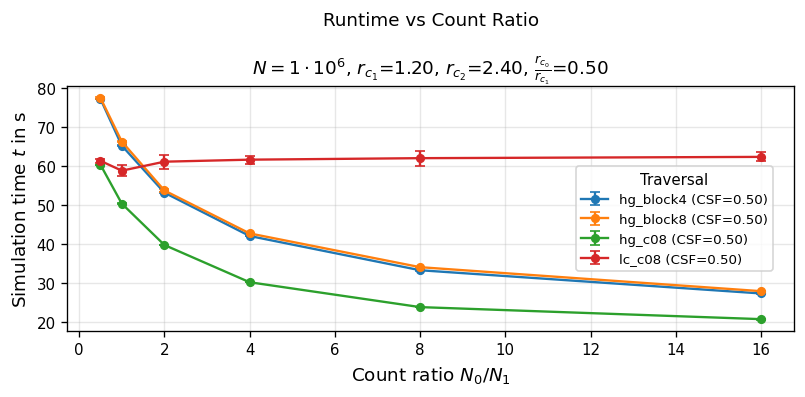

Saved: ../thesis_plots/comparison_sigma_0p50.pdf
Plotted one figure per sigma ratio with traversal lines and Student-t error bars (best cell size per traversal kept; lc_sliced and lc_c04 removed).
Cell size factors handled: [0.5, 1.0]


In [84]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats as scipy_stats
    _HAS_SCIPY = True
except Exception:
    scipy_stats = None
    _HAS_SCIPY = False

def format_scientific_tex(value: int | float, precision: int = 2) -> str:
    """Format a number as mantissa \cdot 10^{exponent} for Matplotlib mathtext."""
    if value == 0:
        return "0"

    mantissa_str, exponent_str = f"{float(value):.{precision}e}".split("e")
    mantissa = float(mantissa_str)
    exponent = int(exponent_str)
    return fr"{mantissa:g} \cdot 10^{{{exponent}}}"


def infer_total_particles_from_input(run_dir: Path) -> int | None:
    """Infer total particles from input.yaml."""
    input_yaml = run_dir / "input.yaml"
    if not input_yaml.exists():
        return None

    total = 0
    pattern = re.compile(r"numberOfParticles\s*:\s*([0-9]+)")
    for line in input_yaml.read_text(encoding="utf-8", errors="replace").splitlines():
        m = pattern.search(line)
        if m:
            total += int(m.group(1))
    return total if total > 0 else None


def infer_level_cutoffs_from_input(run_dir: Path) -> tuple[float, float] | None:
    """Infer per-level cutoffs rc1 and rc2 from input.yaml."""
    input_yaml = run_dir / "input.yaml"
    if not input_yaml.exists():
        return None

    text = input_yaml.read_text(encoding="utf-8", errors="replace")
    match = re.search(
        r"cutoffs\s*:\s*\[\s*([0-9]+(?:\.[0-9]+)?)\s*,\s*([0-9]+(?:\.[0-9]+)?)\s*\]",
        text,
    )
    if not match:
        return None

    return float(match.group(1)), float(match.group(2))


def parse_prefixed_value(parts: tuple[str, ...], prefix: str) -> str | None:
    """Extract value from a path token of the form '<prefix>_<value>'."""
    token = next((p for p in parts if p.startswith(prefix)), None)
    if token is None:
        return None
    return token.split("_", 1)[1]


def collect_runtime_data(base_dir: str | Path = ".") -> pd.DataFrame:
    """Collect simulation times from logOutput files under base_dir recursively.

    Extracts cell_size_factor from the directory path if present.
    """
    base = Path(base_dir).expanduser().resolve()
    rows = []

    for log_path in base.rglob("logOutput_*.out"):
        parts = log_path.parts

        container = parse_prefixed_value(parts, "container_")
        traversal = parse_prefixed_value(parts, "traversal_")
        sigma_ratio_str = parse_prefixed_value(parts, "sigmaRatio_")
        count_ratio_str = parse_prefixed_value(parts, "countRatio_")
        run_str = parse_prefixed_value(parts, "run_")
        cell_size_str = parse_prefixed_value(parts, "cellSize_")

        if None in {container, traversal, sigma_ratio_str, count_ratio_str, run_str}:
            continue

        # Requested exclusion: skip all c04_hcp traversal variants with cell size factor 0.5
        # directly from path tokens during ingestion.
        traversal_normalized = traversal.lower()
        if "c04_hcp" in traversal_normalized and cell_size_str in {"0p5", "0p50", "0.5", "0.50"}:
            continue

        sigma_ratio = float(sigma_ratio_str.replace("p", "."))
        count_ratio = float(count_ratio_str.replace("p", "."))
        run = int(run_str)
        cell_size = float(cell_size_str.replace("p", ".")) if cell_size_str else None

        total_particles = infer_total_particles_from_input(log_path.parent)
        level_cutoffs = infer_level_cutoffs_from_input(log_path.parent)
        if total_particles is None or level_cutoffs is None:
            continue
        cutoff_1, cutoff_2 = level_cutoffs

        timing = read_simulation_time(log_path)
        rows.append(
            {
                "container": container,
                "traversal": traversal,
                "total_particles": total_particles,
                "cutoff_1": cutoff_1,
                "cutoff_2": cutoff_2,
                "sigma_ratio": sigma_ratio,
                "count_ratio": count_ratio,
                "cell_size": cell_size,
                "run": run,
                "seconds": timing["seconds"],
                "log_file": str(log_path),
            }
        )

    return pd.DataFrame(rows)


def normalize_traversal_name(name: str) -> str:
    """Rename traversal names for display."""
    name = name.replace("hgrid_block4", "hg_block4")
    name = name.replace("hgrid_block8", "hg_block8")
    name = name.replace("hgrid_matching", "hg_c08")
    return name


def t_critical(confidence: float, dof: int) -> float:
    """Two-sided t critical value for a given central confidence and dof."""
    if dof <= 0:
        return 0.0

    p = (1.0 + confidence) / 2.0

    if _HAS_SCIPY:
        return float(scipy_stats.t.ppf(p, dof))

    z_lookup = {
        0.68: 0.994,
        0.86: 1.080,
        0.90: 1.645,
        0.95: 1.960,
        0.99: 2.576,
    }
    return z_lookup.get(round(confidence, 2), 1.96)


def apply_scrbook_11pt_style(use_latex: bool = False):
    """Style settings tuned for thesis figures included at ~\textwidth in scrbook 11pt."""
    plt.rcParams.update(
        {
            "figure.dpi": 120,
            "savefig.dpi": 600,
            "font.size": 11,
            "axes.titlesize": 11,
            "axes.labelsize": 11,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "legend.fontsize": 9,
            "legend.title_fontsize": 9,
            "lines.linewidth": 1.4,
            "lines.markersize": 4.5,
            "axes.grid": True,
            "grid.alpha": 0.3,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "text.usetex": use_latex,
        }
    )


def plot_runtime_vs_count_ratio_for_sigma(
    df: pd.DataFrame,
    sigma_ratio: float,
    ax=None,
    error_mode: str = "t86",
):
    """Plot runtime vs count ratio at one sigma ratio with one best cell size per traversal."""
    subset = df[df["sigma_ratio"].round(6).eq(round(sigma_ratio, 6))].copy()

    # Exclude traversal variants requested for plots.
    traversal_lc = subset["traversal"].str.lower()
    subset = subset[~traversal_lc.eq("lc_sliced")]
    subset = subset[~traversal_lc.str.contains("lc_c04", regex=False)]

    if subset.empty:
        raise ValueError(f"No rows found for sigma_ratio={sigma_ratio!r}.")

    total_particles_values = sorted(subset["total_particles"].dropna().astype(int).unique().tolist())
    cutoff_1_values = sorted(subset["cutoff_1"].dropna().round(12).unique().tolist())
    cutoff_2_values = sorted(subset["cutoff_2"].dropna().round(12).unique().tolist())

    if len(total_particles_values) != 1 or len(cutoff_1_values) != 1 or len(cutoff_2_values) != 1:
        raise ValueError(
            "Expected constant total particles and per-level cutoffs per sigma plot, but found "
            f"N={total_particles_values}, rc1={cutoff_1_values}, rc2={cutoff_2_values}."
        )

    total_particles = total_particles_values[0]
    cutoff_1 = cutoff_1_values[0]
    cutoff_2 = cutoff_2_values[0]

    summary = (
        subset.groupby(["container", "traversal", "count_ratio", "cell_size"], as_index=False)
        .agg(seconds_mean=("seconds", "mean"), seconds_std=("seconds", "std"), n=("seconds", "count"))
        .sort_values(["container", "traversal", "count_ratio", "cell_size"])
    )
    summary["seconds_std"] = summary["seconds_std"].fillna(0.0)

    if error_mode == "std":
        summary["error"] = summary["seconds_std"]
    else:
        confidence = 0.86 if error_mode == "t86" else 0.95
        summary["se"] = summary["seconds_std"] / summary["n"].pow(0.5)
        summary["tcrit"] = summary["n"].apply(lambda n: t_critical(confidence, int(n - 1)))
        summary["error"] = summary["tcrit"] * summary["se"]

    # For each traversal in this sigma plot, keep only the cell size with lower runtime.
    best_cell_sizes = (
        summary.groupby(["traversal", "cell_size"], as_index=False)
        .agg(mean_runtime=("seconds_mean", "mean"))
        .sort_values(["traversal", "mean_runtime", "cell_size"])
        .drop_duplicates(subset=["traversal"], keep="first")
    )[["traversal", "cell_size"]]
    summary = summary.merge(best_cell_sizes, on=["traversal", "cell_size"], how="inner")

    if ax is None:
        _, ax = plt.subplots(figsize=(6.6, 3.2), constrained_layout=True)

    traversal_order = sorted(summary["traversal"].unique().tolist())
    colors = plt.cm.tab10(range(len(traversal_order)))
    color_map = {t: colors[i] for i, t in enumerate(traversal_order)}

    # If different traversals pick different best cell sizes, reflect this via line style.
    cell_sizes = sorted(summary["cell_size"].dropna().unique().tolist())
    line_styles = ["-", "--"]
    cell_size_lines = {cs: line_styles[i % len(line_styles)] for i, cs in enumerate(cell_sizes)}

    for traversal in traversal_order:
        grp = summary[summary["traversal"] == traversal].sort_values("count_ratio")
        if grp.empty:
            continue

        cell_size = float(grp["cell_size"].iloc[0]) if pd.notna(grp["cell_size"].iloc[0]) else None
        linestyle = cell_size_lines.get(cell_size, "-")
        display_traversal = normalize_traversal_name(traversal)
        label = f"{display_traversal} (CSF={cell_size:.2f})" if cell_size is not None else display_traversal

        ax.errorbar(
            grp["count_ratio"],
            grp["seconds_mean"],
            yerr=grp["error"],
            marker="o",
            linestyle=linestyle,
            capsize=3,
            color=color_map[traversal],
            label=label,
        )

    ax.set_title(
        f"Runtime vs Count Ratio\n"
        f"\n$N={format_scientific_tex(total_particles)}$, $r_{{c_1}}$={cutoff_1:.2f}, $r_{{c_2}}$={cutoff_2:.2f}, "
        fr"$\frac{{r_{{c_0}}}}{{r_{{c_1}}}}$={sigma_ratio:.2f}"
    )
    ax.set_xlabel(r"Count ratio $N_0 / N_1$")
    ax.set_ylabel(r"Simulation time $t$ in s")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Traversal", fontsize=8, loc="upper right", bbox_to_anchor=(0.98, 0.7))


# Collect data and generate one figure per sigma ratio
runtime_df = collect_runtime_data(".")

apply_scrbook_11pt_style(use_latex=False)

if runtime_df.empty:
    print("No logOutput_*.out files found below current directory.")
else:
    sigma_values = sorted(runtime_df["sigma_ratio"].unique().tolist())

    output_dir = Path("..") / "thesis_plots"
    output_dir.mkdir(exist_ok=True)

    for sigma in [0.5]:
        fig, ax = plt.subplots(1, 1, figsize=(6.6, 3.2), constrained_layout=True)
        plot_runtime_vs_count_ratio_for_sigma(runtime_df, sigma, ax=ax, error_mode="t86")

        sigma_tag = f"{sigma:.2f}".replace(".", "p")
        pdf_path = output_dir / f"comparison_sigma_{sigma_tag}.pdf"
        fig.savefig(pdf_path, bbox_inches="tight")
        plt.show()
        print(f"Saved: {pdf_path}")

    print("Plotted one figure per sigma ratio with traversal lines and Student-t error bars (best cell size per traversal kept; lc_sliced and lc_c04 removed).")
    print(f"Cell size factors handled: {sorted(runtime_df['cell_size'].dropna().unique().tolist())}")


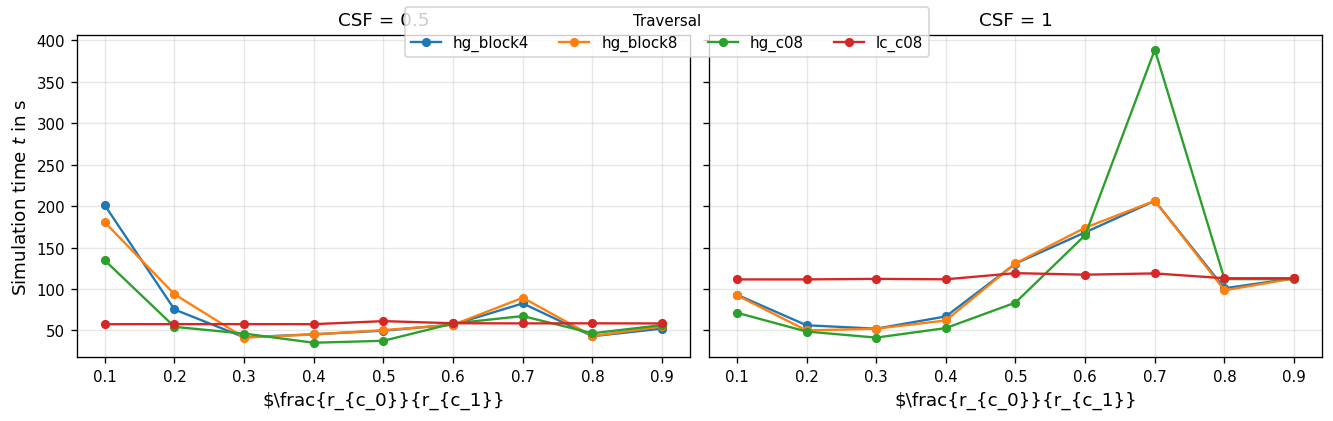

Low sigma ratio, means a lot of small cells, for low particle counts, many of the empty, so not worth having so many
Because of this, here csf=1 favorable, less cells
For higher sigmas, more cells, so csf=0.5 favorable


In [85]:
# Runtime vs sigma ratio split into two plots: cell size 0.5 and 1.0
if runtime_df.empty:
    print("No data available in runtime_df.")
else:
    sigma_plot_df = runtime_df.copy()

    # Exclude requested sigma ratio.
    sigma_plot_df = sigma_plot_df[~sigma_plot_df["sigma_ratio"].round(6).eq(0.48)]

    # Keep traversal exclusions consistent with the other plots in this notebook.
    traversal_lc = sigma_plot_df["traversal"].str.lower()
    sigma_plot_df = sigma_plot_df[~traversal_lc.eq("lc_sliced")]
    sigma_plot_df = sigma_plot_df[~traversal_lc.str.contains("lc_c04", regex=False)]

    summary = (
        sigma_plot_df.groupby(["traversal", "cell_size", "sigma_ratio"], as_index=False)
        .agg(seconds_mean=("seconds", "mean"))
        .sort_values(["traversal", "cell_size", "sigma_ratio"])
)

    target_cell_sizes = [0.5, 1.0]
    summary = summary[summary["cell_size"].isin(target_cell_sizes)]

    if summary.empty:
        print("No rows left after filtering (sigma ratio != 0.48 and cell sizes in {0.5, 1.0}).")
    else:
        fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.4), constrained_layout=True, sharey=True)

        traversal_order = sorted(summary["traversal"].unique().tolist())
        colors = plt.cm.tab10(range(len(traversal_order)))
        color_map = {t: colors[i] for i, t in enumerate(traversal_order)}

        for ax, cell_size in zip(axes, target_cell_sizes):
            sub = summary[summary["cell_size"].round(6).eq(round(cell_size, 6))]

            for traversal in traversal_order:
                grp = sub[sub["traversal"] == traversal].sort_values("sigma_ratio")
                if grp.empty:
                    continue
                display_traversal = normalize_traversal_name(traversal)
                ax.plot(
                    grp["sigma_ratio"],
                    grp["seconds_mean"],
                    marker="o",
                    linestyle="-",
                    color=color_map[traversal],
                    label=display_traversal,
                )

            ax.set_title(f"CSF = {cell_size:g}")
            ax.set_xlabel(r"$\frac{r_{c_0}}{r_{c_1}}")
            ax.grid(True, alpha=0.3)

        axes[0].set_ylabel(r"Simulation time $t$ in s")

        handles, labels = axes[0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, title="Traversal", loc="upper center", ncol=min(4, len(labels)))

        plt.show()
        print("Low sigma ratio, means a lot of small cells, for low particle counts, many of the empty, so not worth having so many")
        print("Because of this, here csf=1 favorable, less cells")
        print("For higher sigmas, more cells, so csf=0.5 favorable")

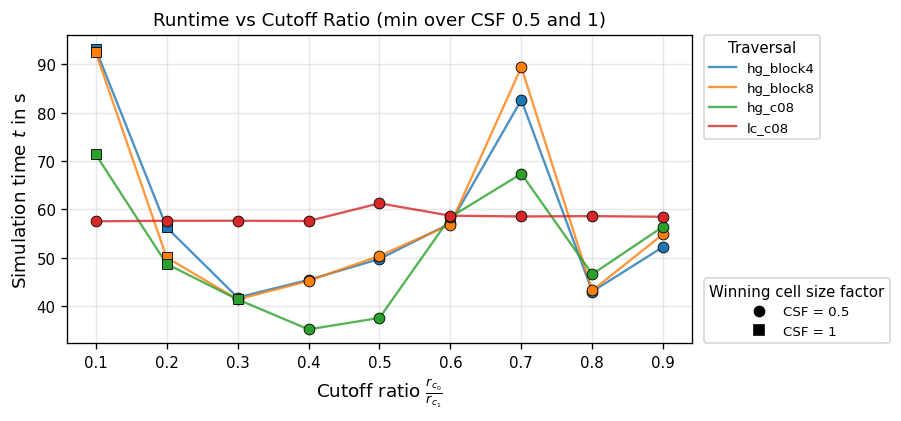

Saved: /home/alex_hackerman/bachelorInfo/AutoPas/performanceTests/thesis_plots/bestCaseCompare.pdf


In [86]:
# Runtime vs sigma ratio: minimum runtime over cell sizes 0.5 and 1.0
if runtime_df.empty:
    print("No data available in runtime_df.")
else:
    sigma_plot_df = runtime_df.copy()

    # Exclude requested sigma ratio.
    sigma_plot_df = sigma_plot_df[~sigma_plot_df["sigma_ratio"].round(6).eq(0.48)]

    # Keep traversal exclusions consistent with the other plots in this notebook.
    traversal_lc = sigma_plot_df["traversal"].str.lower()
    sigma_plot_df = sigma_plot_df[~traversal_lc.eq("lc_sliced")]
    sigma_plot_df = sigma_plot_df[~traversal_lc.str.contains("lc_c04", regex=False)]

    summary = (
        sigma_plot_df.groupby(["traversal", "cell_size", "sigma_ratio"], as_index=False)
        .agg(seconds_mean=("seconds", "mean"))
        .sort_values(["traversal", "cell_size", "sigma_ratio"])
)

    target_cell_sizes = [0.5, 1.0]
    summary = summary[summary["cell_size"].isin(target_cell_sizes)]

    if summary.empty:
        print("No rows left after filtering (sigma ratio != 0.48 and cell sizes in {0.5, 1.0}).")
    else:
        # Keep the minimum runtime per traversal and sigma ratio, but preserve which cell size won.
        summary_min = summary.loc[
            summary.groupby(["traversal", "sigma_ratio"])["seconds_mean"].idxmin()
        ].sort_values(["traversal", "sigma_ratio"])

        fig, ax = plt.subplots(1, 1, figsize=(7.4, 3.4), constrained_layout=True)

        traversal_order = sorted(summary_min["traversal"].unique().tolist())
        colors = plt.cm.tab10(range(len(traversal_order)))
        color_map = {t: colors[i] for i, t in enumerate(traversal_order)}
        marker_map = {0.5: "o", 1.0: "s"}

        for traversal in traversal_order:
            grp = summary_min[summary_min["traversal"] == traversal].sort_values("sigma_ratio")
            if grp.empty:
                continue

            color = color_map[traversal]
            display_traversal = normalize_traversal_name(traversal)

            # Draw the line once per traversal, then encode the winning cell size in the markers.
            ax.plot(
                grp["sigma_ratio"],
                grp["seconds_mean"],
                linestyle="-",
                linewidth=1.4,
                color=color,
                alpha=0.8,
                label=display_traversal,
            )

            for cell_size, marker in marker_map.items():
                cell_grp = grp[grp["cell_size"].round(6).eq(round(cell_size, 6))]
                if cell_grp.empty:
                    continue

                ax.scatter(
                    cell_grp["sigma_ratio"],
                    cell_grp["seconds_mean"],
                    marker=marker,
                    s=42,
                    color=color,
                    edgecolors="black",
                    linewidths=0.5,
                    zorder=3,
                )

        from matplotlib.lines import Line2D

        traversal_handles, traversal_labels = ax.get_legend_handles_labels()
        cell_size_handles = [
            Line2D(
                [0],
                [0],
                marker=marker_map[cell_size],
                color="black",
                linestyle="None",
                markersize=6,
                label=f"CSF = {cell_size:g}",
            )
            for cell_size in target_cell_sizes
        ]

        ax.set_title("Runtime vs Cutoff Ratio (min over CSF 0.5 and 1)")
        ax.set_xlabel(r"Cutoff ratio $\frac{r_{c_0}}{r_{c_1}}$")
        ax.set_ylabel(r"Simulation time $t$ in s")
        ax.grid(True, alpha=0.3)
        #ax.set_yscale("log")

        traversal_legend = ax.legend(
            traversal_handles,
            traversal_labels,
            title="Traversal",
            fontsize=8,
            loc="upper left",
            bbox_to_anchor=(1.02, 1.0),
            borderaxespad=0.0,
        )
        ax.add_artist(traversal_legend)
        ax.legend(
            handles=cell_size_handles,
            title="Winning cell size factor",
            fontsize=8,
            loc="lower left",
            bbox_to_anchor=(1.02, 0.0),
            borderaxespad=0.0,
        )

        output_dir = Path("..") / ".." / "thesis_plots"
        output_dir.mkdir(parents=True, exist_ok=True)
        pdf_path = output_dir / "bestCaseCompare.pdf"
        fig.savefig(pdf_path, bbox_inches="tight")

        plt.show()
        print(f"Saved: {pdf_path.resolve()}")

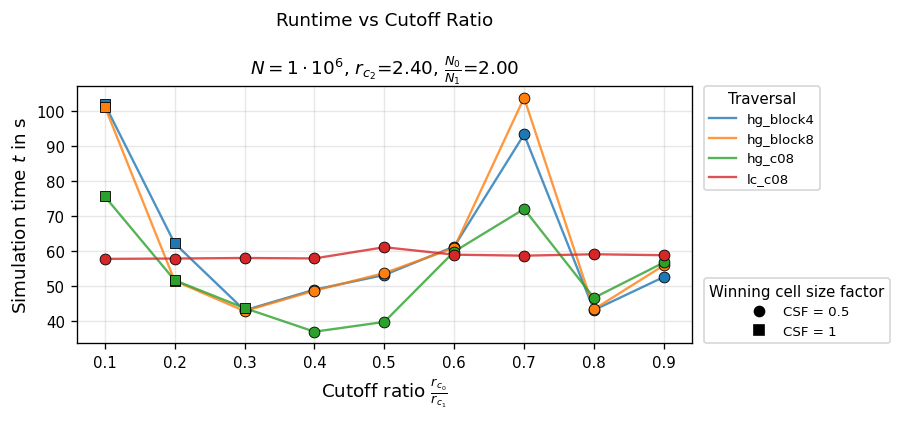

Saved: /home/alex_hackerman/bachelorInfo/AutoPas/performanceTests/thesis_plots/bestCaseCompare_countRatio_4p00.pdf


In [97]:
# Runtime vs sigma ratio: minimum runtime over cell sizes 0.5 and 1.0 for fixed count ratio N0/N1 = 4
if runtime_df.empty:
    print("No data available in runtime_df.")
else:
    sigma_plot_df = runtime_df.copy()

    # Keep only the requested fixed count ratio.
    target_count_ratio = 2.0
    sigma_plot_df = sigma_plot_df[sigma_plot_df["count_ratio"].round(6).eq(round(target_count_ratio, 6))]

    # Exclude requested sigma ratio.
    sigma_plot_df = sigma_plot_df[~sigma_plot_df["sigma_ratio"].round(6).eq(0.48)]

    # Keep traversal exclusions consistent with the other plots in this notebook.
    traversal_lc = sigma_plot_df["traversal"].str.lower()
    sigma_plot_df = sigma_plot_df[~traversal_lc.eq("lc_sliced")]
    sigma_plot_df = sigma_plot_df[~traversal_lc.str.contains("lc_c04", regex=False)]

    total_particles_values = sorted(sigma_plot_df["total_particles"].dropna().astype(int).unique().tolist())
    cutoff_2_values = sorted(sigma_plot_df["cutoff_2"].dropna().round(12).unique().tolist())
    if len(total_particles_values) != 1 or len(cutoff_2_values) != 1:
        raise ValueError(
            "Expected constant total particles and upper cutoff for the sigma plot, but found "
            f"N={total_particles_values}, rc2={cutoff_2_values}."
        )

    total_particles = total_particles_values[0]
    cutoff_2 = cutoff_2_values[0]

    summary = (
        sigma_plot_df.groupby(["traversal", "cell_size", "sigma_ratio"], as_index=False)
        .agg(seconds_mean=("seconds", "mean"))
        .sort_values(["traversal", "cell_size", "sigma_ratio"])
    )

    target_cell_sizes = [0.5, 1.0]
    summary = summary[summary["cell_size"].isin(target_cell_sizes)]

    if summary.empty:
        print("No rows left after filtering (count ratio = 4.0, sigma ratio != 0.48, cell sizes in {0.5, 1.0}).")
    else:
        # Keep the minimum runtime per traversal and sigma ratio, but preserve which cell size won.
        summary_min = summary.loc[
            summary.groupby(["traversal", "sigma_ratio"])["seconds_mean"].idxmin()
        ].sort_values(["traversal", "sigma_ratio"])

        fig, ax = plt.subplots(1, 1, figsize=(7.4, 3.4), constrained_layout=True)

        traversal_order = sorted(summary_min["traversal"].unique().tolist())
        colors = plt.cm.tab10(range(len(traversal_order)))
        color_map = {t: colors[i] for i, t in enumerate(traversal_order)}
        marker_map = {0.5: "o", 1.0: "s"}

        for traversal in traversal_order:
            grp = summary_min[summary_min["traversal"] == traversal].sort_values("sigma_ratio")
            if grp.empty:
                continue

            color = color_map[traversal]
            display_traversal = normalize_traversal_name(traversal)

            # Draw the line once per traversal, then encode the winning cell size in the markers.
            ax.plot(
                grp["sigma_ratio"],
                grp["seconds_mean"],
                linestyle="-",
                linewidth=1.4,
                color=color,
                alpha=0.8,
                label=display_traversal,
            )

            for cell_size, marker in marker_map.items():
                cell_grp = grp[grp["cell_size"].round(6).eq(round(cell_size, 6))]
                if cell_grp.empty:
                    continue

                ax.scatter(
                    cell_grp["sigma_ratio"],
                    cell_grp["seconds_mean"],
                    marker=marker,
                    s=42,
                    color=color,
                    edgecolors="black",
                    linewidths=0.5,
                    zorder=3,
                )

        from matplotlib.lines import Line2D

        traversal_handles, traversal_labels = ax.get_legend_handles_labels()
        cell_size_handles = [
            Line2D(
                [0],
                [0],
                marker=marker_map[cell_size],
                color="black",
                linestyle="None",
                markersize=6,
                label=f"CSF = {cell_size:g}",
            )
            for cell_size in target_cell_sizes
        ]

        ax.set_title(
            f"Runtime vs Cutoff Ratio\n"
            f"\n$N={format_scientific_tex(total_particles)}$, $r_{{c_2}}$={cutoff_2:.2f}, "
            fr"$\frac{{N_0}}{{N_1}}$={target_count_ratio:.2f}"
        )
        ax.set_xlabel(r"Cutoff ratio $\frac{r_{c_0}}{r_{c_1}}$")
        ax.set_ylabel(r"Simulation time $t$ in s")
        ax.grid(True, alpha=0.3)
        #ax.set_yscale("log")

        traversal_legend = ax.legend(
            traversal_handles,
            traversal_labels,
            title="Traversal",
            fontsize=8,
            loc="upper left",
            bbox_to_anchor=(1.02, 1.0),
            borderaxespad=0.0,
        )
        ax.add_artist(traversal_legend)
        ax.legend(
            handles=cell_size_handles,
            title="Winning cell size factor",
            fontsize=8,
            loc="lower left",
            bbox_to_anchor=(1.02, 0.0),
            borderaxespad=0.0,
        )

        output_dir = Path("..") / ".." / "thesis_plots"
        output_dir.mkdir(parents=True, exist_ok=True)
        pdf_path = output_dir / "bestCaseCompare_countRatio_4p00.pdf"
        fig.savefig(pdf_path, bbox_inches="tight")

        plt.show()
        print(f"Saved: {pdf_path.resolve()}")

In [96]:
# Full ranked speedup tables: hg_c08 vs lc_c08 / hg_block4 / hg_block8 across all shared points.
import pandas as pd
from pathlib import Path

if 'runtime_df' not in globals() or runtime_df.empty:
    raise RuntimeError('runtime_df is not available.')

analysis_df = runtime_df.copy()
analysis_df = analysis_df[~analysis_df['traversal'].str.lower().eq('lc_sliced')]
analysis_df = analysis_df[~analysis_df['traversal'].str.lower().str.contains('lc_c04', regex=False)]

name_map = {
    'hgrid_block4': 'hg_block4',
    'hgrid_block8': 'hg_block8',
    'hgrid_matching': 'hg_c08',
    'lc_c08': 'lc_c08',
}
analysis_df = analysis_df[analysis_df['traversal'].isin(name_map.keys())].copy()
analysis_df['traversal_display'] = analysis_df['traversal'].map(name_map)

# Keep one runtime per traversal per point: best available cell-size for that traversal at that point.
best = (
    analysis_df.groupby(['sigma_ratio', 'count_ratio', 'traversal_display', 'cell_size'], as_index=False)
    .agg(seconds_mean=('seconds', 'mean'))
)
best = best.loc[
    best.groupby(['sigma_ratio', 'count_ratio', 'traversal_display'])['seconds_mean'].idxmin()
].reset_index(drop=True)

pivot = best.pivot_table(
    index=['sigma_ratio', 'count_ratio'],
    columns='traversal_display',
    values='seconds_mean',
    aggfunc='mean',
)

out_dir = Path('..') / '..' / 'thesis_plots'
out_dir.mkdir(parents=True, exist_ok=True)

summ_rows = []
for target in ['lc_c08', 'hg_block4', 'hg_block8']:
    common = pivot[['hg_c08', target]].dropna().copy().reset_index()
    common['speedup'] = common[target] / common['hg_c08']
    ranked = common.sort_values('speedup', ascending=False).reset_index(drop=True)

    csv_path = out_dir / f'speedup_ranked_hg_c08_vs_{target}.csv'
    ranked.to_csv(csv_path, index=False)

    top = ranked.iloc[0]
    summ_rows.append({
        'against': target,
        'shared_points': len(ranked),
        'max_speedup': top['speedup'],
        'sigma_ratio': top['sigma_ratio'],
        'count_ratio': top['count_ratio'],
        'csv': str(csv_path.resolve()),
    })

summary_df = pd.DataFrame(summ_rows)
print(summary_df.to_string(index=False))

  against  shared_points  max_speedup  sigma_ratio  count_ratio                                                                                                            csv
   lc_c08             60     4.480707          0.3         16.0    /home/alex_hackerman/bachelorInfo/AutoPas/performanceTests/thesis_plots/speedup_ranked_hg_c08_vs_lc_c08.csv
hg_block4             60     1.452853          0.7          4.0 /home/alex_hackerman/bachelorInfo/AutoPas/performanceTests/thesis_plots/speedup_ranked_hg_c08_vs_hg_block4.csv
hg_block8             60     1.531530          0.7          4.0 /home/alex_hackerman/bachelorInfo/AutoPas/performanceTests/thesis_plots/speedup_ranked_hg_c08_vs_hg_block8.csv


In [95]:
# Max difference for hg_c08 between CSF=0.5 and CSF=1.0 for identical setups.
import pandas as pd

if 'runtime_df' not in globals() or runtime_df.empty:
    raise RuntimeError('runtime_df is not available.')

df = runtime_df.copy()
df = df[df['traversal'].str.lower().eq('hgrid_matching')]

# Compare same setup otherwise: same sigma_ratio and count_ratio.
agg = (
    df.groupby(['sigma_ratio', 'count_ratio', 'cell_size'], as_index=False)
      .agg(seconds_mean=('seconds', 'mean'))
)

p = agg.pivot_table(
    index=['sigma_ratio', 'count_ratio'],
    columns='cell_size',
    values='seconds_mean',
    aggfunc='mean'
).dropna(subset=[0.5, 1.0]).reset_index()

p['abs_diff_s'] = (p[1.0] - p[0.5]).abs()
p['speedup_1_over_0p5'] = p[0.5] / p[1.0]
p['speedup_0p5_over_1'] = p[1.0] / p[0.5]
p['faster_csf'] = p.apply(lambda r: 1.0 if r[1.0] < r[0.5] else 0.5, axis=1)

best_abs = p.loc[p['abs_diff_s'].idxmax()]
best_ratio = p.loc[p['speedup_0p5_over_1'].idxmax()]

print('Compared points:', len(p))
print('\nMax absolute time difference (same setup):')
print(best_abs[['sigma_ratio', 'count_ratio', 0.5, 1.0, 'abs_diff_s', 'faster_csf']].to_string())

print('\nMax multiplicative difference (best speedup between CSFs):')
print(best_ratio[['sigma_ratio', 'count_ratio', 0.5, 1.0, 'speedup_0p5_over_1', 'speedup_1_over_0p5', 'faster_csf']].to_string())

# Save full comparison table
out_path = '../../thesis_plots/hg_c08_csf0p5_vs_csf1p0_same_setup.csv'
p.sort_values(['sigma_ratio', 'count_ratio']).to_csv(out_path, index=False)
print(f'\nSaved full table: {Path(out_path).resolve()}')

Compared points: 60

Max absolute time difference (same setup):
cell_size
sigma_ratio      0.700000
count_ratio      0.500000
0.5            103.709333
1.0            707.589000
abs_diff_s     603.879667
faster_csf       0.500000

Max multiplicative difference (best speedup between CSFs):
cell_size
sigma_ratio             0.700000
count_ratio             0.500000
0.5                   103.709333
1.0                   707.589000
speedup_0p5_over_1      6.822809
speedup_1_over_0p5      0.146567
faster_csf              0.500000

Saved full table: /home/alex_hackerman/bachelorInfo/AutoPas/performanceTests/thesis_plots/hg_c08_csf0p5_vs_csf1p0_same_setup.csv
